In [6]:
import torch
import numpy as np
import glob
import h5py
from torch.utils.data import Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_path = "/kaggle/input/datasets/arafatshovon/fastmri-knee-multicoil"

def undersample_mask(H, W, accel=4):
    mask = np.zeros((H, W), dtype=np.float32)
    center = H // 2
    num_low = int(H * 0.08)

    mask[center - num_low//2:center + num_low//2] = 1

    for i in range(H):
        if np.random.rand() < 1/accel:
            mask[i] = 1

    return mask


class FastMRIDataset(Dataset):
    def __init__(self, root):
        self.files = glob.glob(root + "/**/*.h5", recursive=True)
        print(f" {len(self.files)} arquivos encontrados")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        with h5py.File(self.files[idx], 'r') as f:
            kspace = f['kspace'][()]
            slice_idx = np.random.randint(0, kspace.shape[0])
            kspace = kspace[slice_idx]

        kspace = torch.tensor(kspace, dtype=torch.complex64)
        kspace = torch.view_as_real(kspace).float()

        #  NORMALIZAÇÃO 
        mean = kspace.mean()
        std = kspace.std()
        kspace = (kspace - mean) / (std + 1e-8)

        Nc, H, W, _ = kspace.shape

        mask_np = undersample_mask(H, W)
        mask = torch.tensor(mask_np).unsqueeze(0).unsqueeze(-1).float()
        mask = mask.repeat(Nc, 1, 1, 2)

        kspace_us = kspace * mask

        return kspace_us, kspace, mask

In [7]:
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(2, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 2, 3, padding=1)
        )

    def forward(self, x):
        B, Nc, H, W, _ = x.shape

        x_input = x

        x = x.permute(0,1,4,2,3).reshape(B*Nc, 2, H, W)
        out = self.net(x)

        out = out.reshape(B, Nc, 2, H, W).permute(0,1,3,4,2)

        return x_input + out  # residual


In [8]:
def ifft2c(kspace):
    kspace = torch.view_as_complex(kspace)
    img = torch.fft.ifft2(kspace)
    return torch.abs(img)


#  usar APENAS na inferência
def apply_data_consistency(kspace_pred, kspace_us, mask):
    return (1 - mask) * kspace_pred + mask * kspace_us


#  LOSS 
def reconstruction_loss(kspace_pred, kspace_gt, mask):
    missing = (1 - mask)
    return torch.mean(((kspace_pred - kspace_gt) * missing) ** 2)

In [9]:
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm

print("TREINO FINAL")

dataset = FastMRIDataset(train_path)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

model = UNet().to(device)
opt = Adam(model.parameters(), lr=1e-4)

STEPS = 400
data_iter = iter(loader)

for step in tqdm(range(STEPS)):
    try:
        kspace_us, kspace_gt, mask = next(data_iter)
    except StopIteration:
        data_iter = iter(loader)
        kspace_us, kspace_gt, mask = next(data_iter)

    kspace_us = kspace_us.to(device)
    kspace_gt = kspace_gt.to(device)
    mask = mask.to(device)

    #  forward (SEM data consistency)
    kspace_pred = model(kspace_us)

    #  loss
    loss = reconstruction_loss(kspace_pred, kspace_gt, mask)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % 10 == 0:
        print(f"Step {step} | Loss: {loss.item():.6f}")

torch.save(model.state_dict(), "/kaggle/working/model_final.pth")

print("Treino finalizado")

TREINO FINAL
 194 arquivos encontrados


  0%|          | 1/400 [00:04<29:58,  4.51s/it]

Step 0 | Loss: 0.091734


  3%|▎         | 11/400 [00:50<30:33,  4.71s/it]

Step 10 | Loss: 0.124809


...

Step 380 | Loss: 0.011375


 98%|█████████▊| 391/400 [32:15<00:42,  4.75s/it]

Step 390 | Loss: 0.066112


100%|██████████| 400/400 [32:58<00:00,  4.95s/it]


Treino finalizado


PSNR: 26.784042358398438
SSIM: 0.9581547975540161


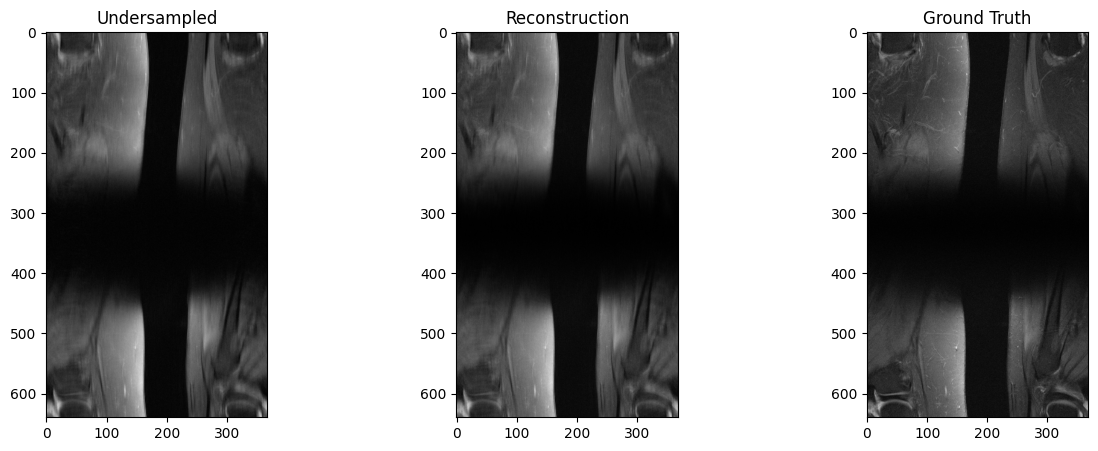

In [10]:
import matplotlib.pyplot as plt

def psnr(img1, img2):
    mse = torch.mean((img1 - img2)**2)
    return 20 * torch.log10(torch.max(img2) / torch.sqrt(mse + 1e-8))


def ssim(img1, img2):
    C1 = 0.01**2
    C2 = 0.03**2

    mu1 = img1.mean()
    mu2 = img2.mean()

    sigma1 = ((img1 - mu1)**2).mean()
    sigma2 = ((img2 - mu2)**2).mean()
    sigma12 = ((img1 - mu1)*(img2 - mu2)).mean()

    return ((2*mu1*mu2 + C1)*(2*sigma12 + C2)) / ((mu1**2 + mu2**2 + C1)*(sigma1 + sigma2 + C2))


def to_image(kspace):
    img = ifft2c(kspace)
    img = torch.sqrt((img ** 2).sum(dim=1))  # RSS
    return img


# pegar exemplo
kspace_us, kspace_gt, mask = dataset[0]

kspace_us = kspace_us.unsqueeze(0).to(device)
kspace_gt = kspace_gt.unsqueeze(0).to(device)
mask = mask.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    kspace_pred = model(kspace_us)

    #  AGORA sim aplicar data consistency
    kspace_pred = apply_data_consistency(kspace_pred, kspace_us, mask)


img_us = to_image(kspace_us)[0].cpu()
img_pred = to_image(kspace_pred)[0].cpu()
img_gt = to_image(kspace_gt)[0].cpu()


def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)


img_us = normalize(img_us)
img_pred = normalize(img_pred)
img_gt = normalize(img_gt)


print("PSNR:", psnr(img_pred, img_gt).item())
print("SSIM:", ssim(img_pred, img_gt).item())


plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_us, cmap='gray')
plt.title("Undersampled")

plt.subplot(1,3,2)
plt.imshow(img_pred, cmap='gray')
plt.title("Reconstruction")

plt.subplot(1,3,3)
plt.imshow(img_gt, cmap='gray')
plt.title("Ground Truth")

plt.show()
